In [1]:
!pip install fredapi


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

In [32]:
fred = Fred(api_key='ecd5252612b65ff032f9f365bd3adffb')

In [34]:
# Dollar index (weekly)
dollar = fred.get_series('RTWEXBGS')

# Exports (quarterly)
exports = fred.get_series('EXPGS')

# Convert to DataFrame
dollar = dollar.to_frame(name='RTWEXBGS')
exports = exports.to_frame(name='EXPGS')

# Ensure datetime index
dollar.index = pd.to_datetime(dollar.index)
exports.index = pd.to_datetime(exports.index)

In [35]:
# Convert both to quarterly PERIOD index
dollar_q = dollar.resample('Q').mean()
dollar_q.index = dollar_q.index.to_period('Q')

exports.index = exports.index.to_period('Q')

/tmp/ipykernel_8604/2079235885.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dollar_q = dollar.resample('Q').mean()


In [36]:
# Create lag AFTER fixing index
exports['EXPGS_lag2'] = exports['EXPGS'].shift(2)

# Merge on aligned quarterly index
merged = pd.merge(dollar_q, exports, left_index=True, right_index=True, how='inner')

print(merged.head())
print("Shape:", merged.shape)

          RTWEXBGS     EXPGS  EXPGS_lag2
2006Q1  100.257400  1413.966    1302.315
2006Q2   99.025733  1459.767    1350.743
2006Q3   98.912500  1475.417    1413.966
2006Q4   97.489967  1531.531    1459.767
2007Q1   97.634967  1577.991    1475.417
Shape: (80, 3)


In [37]:
merged['usd_pct'] = merged['RTWEXBGS'].pct_change()
merged['exports_pct'] = merged['EXPGS_lag2'].pct_change()

In [38]:
merged = merged.dropna()

In [39]:
corr = merged['usd_pct'].corr(merged['exports_pct'])
print("Correlation between USD and lagged exports:", corr)

Correlation between USD and lagged exports: 0.22296791788408507


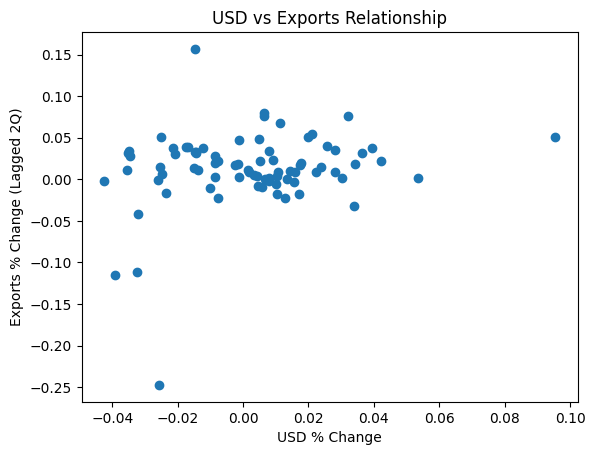

In [40]:
plt.figure()
plt.scatter(merged['usd_pct'], merged['exports_pct'])
plt.xlabel('USD % Change')
plt.ylabel('Exports % Change (Lagged 2Q)')
plt.title('USD vs Exports Relationship')
plt.show()

In [41]:
pre_2020 = merged[merged.index < '2020Q1']
post_2020 = merged[merged.index >= '2020Q1']

print("Pre-2020:", pre_2020['usd_pct'].corr(pre_2020['exports_pct']))
print("Post-2020:", post_2020['usd_pct'].corr(post_2020['exports_pct']))

Pre-2020: 0.18457648346086797
Post-2020: 0.3234371718957543


In [42]:
results = {}

for lag in range(0, 5):  # test lag 0 to 4 quarters
    merged[f'lag_{lag}'] = merged['EXPGS'].shift(lag)

    temp = merged[['RTWEXBGS', f'lag_{lag}']].dropna()

    temp['usd_pct'] = temp['RTWEXBGS'].pct_change()
    temp['exports_pct'] = temp[f'lag_{lag}'].pct_change()

    temp = temp.dropna()

    corr = temp['usd_pct'].corr(temp['exports_pct'])
    results[lag] = corr

print(results)

{0: np.float64(-0.4722964221803226), 1: np.float64(0.05243433921175267), 2: np.float64(0.23514073795103838), 3: np.float64(0.18722676662587315), 4: np.float64(0.030807440646620794)}
